# Baseline — Regressão Linear (OLS)

Notebook de baseline com Regressão Linear usando `data/processed/gold_features.csv`.

Mantém **exatamente** o mesmo setup dos experimentos CNN/GRU/XGBoost:
- janelas de 60 dias achatadas em vetor (60 × 19 = 1 140 features)
- horizontes de 5, 15 e 30 dias
- alvo em log-retorno acumulado
- métricas em preço reconstruído (MAE, RMSE, MAPE%, DirAcc%, MAE/naive)
- plots no mesmo estilo da lib

**Objetivo:** estabelecer um piso de desempenho linear para comparar com os modelos neurais.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import RobustScaler

from src import (
    per_year_metrics,
    plot_predicted_vs_actual,
    plot_price_series,
    plot_residuals,
    plot_return_predictions,
    plot_scatter,
    plot_split_regions,
    plot_yearly_perf,
    regression_metrics,
    temporal_split,
)

from src import ROOT_DIR

REPO_ROOT = ROOT_DIR
SEED = 42
LOOKBACK = 60
HORIZONS = [5, 15, 30]
GAP = max(HORIZONS)
CSV_PATH = REPO_ROOT / "data" / "processed" / "gold_features.csv"

np.random.seed(SEED)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10}
)

print("Repo root:", REPO_ROOT)

Repo root: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast


## Carregamento

In [2]:
def load_processed_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)
    return df


def select_feature_cols(df: pd.DataFrame) -> list[str]:
    blocked = {"date", "close", "open", "high", "low"}
    return [
        col
        for col in df.columns
        if col not in blocked
        and not col.startswith("y_")
        and pd.api.types.is_numeric_dtype(df[col])
        and df[col].nunique(dropna=True) > 1
    ]


df = load_processed_data(CSV_PATH)
feature_cols = select_feature_cols(df)

print(f"{len(df)} linhas | {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"{len(feature_cols)} features")
print(feature_cols)
df.head()

6177 linhas | 2000-08-30 -> 2025-04-14
19 features
['volume', 'log_ret_1', 'log_ret_5', 'log_ret_21', 'vol_5', 'vol_21', 'vol_ratio', 'dist_ma20', 'dist_ma50', 'ma_cross', 'rsi', 'macd_hist', 'boll_b', 'drawdown_252', 'hl_range', 'close_pos', 'gap_open', 'fear_ratio', 'fear_ma5']


,date,close,volume,log_ret_1,log_ret_5,log_ret_21,vol_5,vol_21,vol_ratio,dist_ma20,...,boll_b,drawdown_252,hl_range,close_pos,gap_open,fear_ratio,fear_ma5,y_5,y_15,y_30
0,2000-08-30,273.9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,NaN,0.000000,NaN,0.000365,-0.013231,0.009086
1,2000-08-31,278.3,0,0.015937,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.012576,0.5,0.003280,0.000000,NaN,-0.018130,-0.023633,-0.021428
2,2000-09-01,277.0,0,-0.004682,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004682,0.062500,NaN,-0.014179,-0.010525,-0.020055
3,2000-09-05,275.8,2,-0.004342,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004342,0.111111,NaN,-0.010571,-0.006913,-0.017188
4,2000-09-06,274.2,0,-0.005818,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.005818,0.142857,0.063294,-0.005119,0.015201,-0.014325


## Série histórica

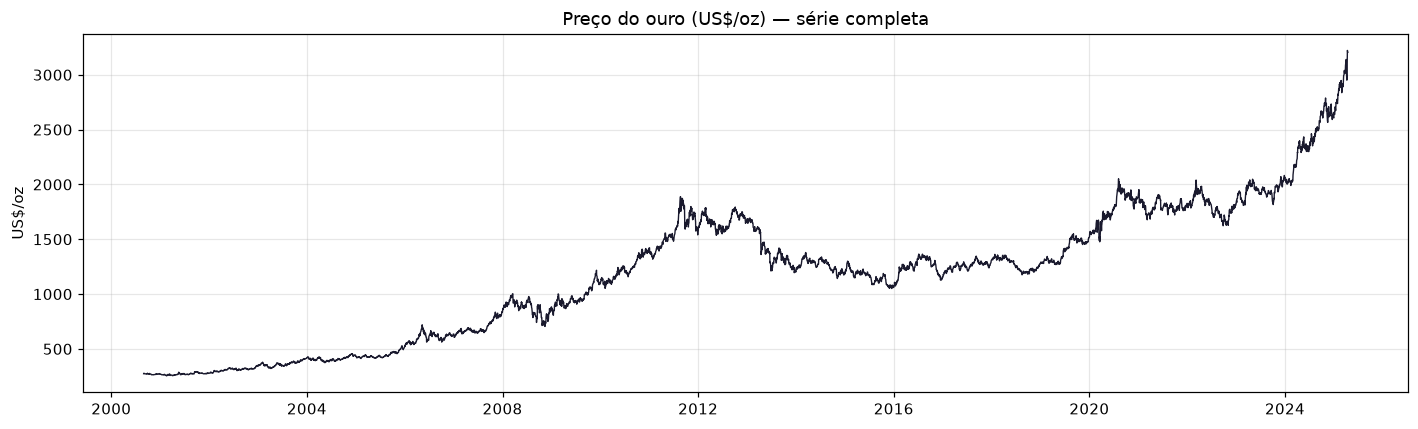

In [3]:
fig = plot_price_series(
    df["date"],
    df["close"],
    title="Preço do ouro (US$/oz) — série completa",
    ylabel="US$/oz",
)
plt.show()

## Split temporal e janelas

In [4]:
splits = temporal_split(
    df=df,
    feature_cols=feature_cols,
    horizons=HORIZONS,
    lookback=LOOKBACK,
    gap=GAP,
)

for name, ws in splits.items():
    d0 = df["date"].iloc[ws.idx[0]].date()
    d1 = df["date"].iloc[ws.idx[-1]].date()
    print(f"{name:>6}: {ws.X.shape} | {d0} -> {d1}")

treino: (4013, 60, 19) | 2001-11-29 -> 2017-11-27
   val: (837, 60, 19) | 2018-04-11 -> 2021-08-05
 teste: (807, 60, 19) | 2021-12-14 -> 2025-03-03


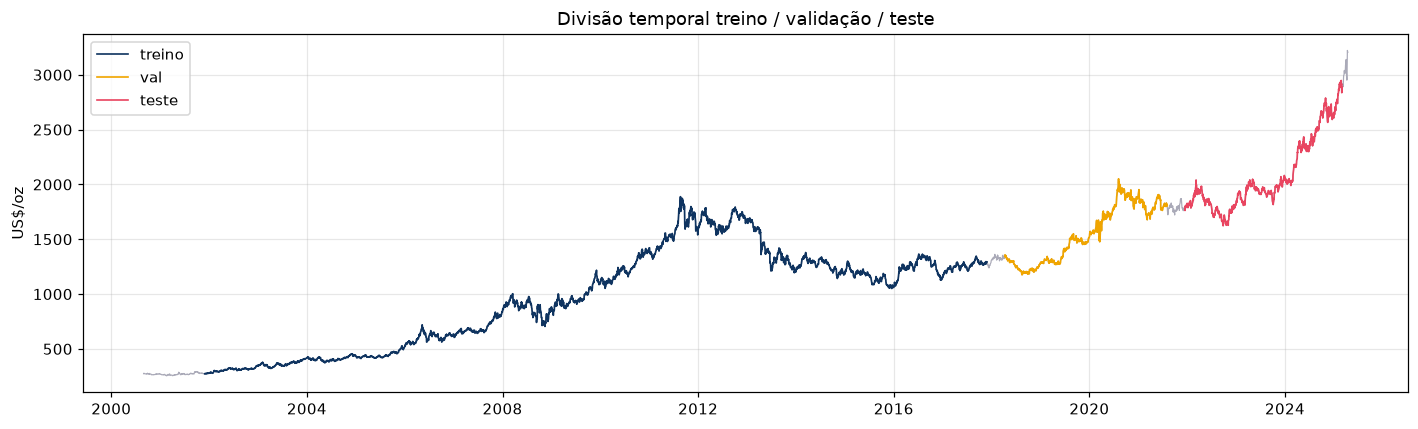

In [5]:
fig = plot_split_regions(
    df,
    {name: (ws.X, ws.Y, ws.prices, ws.idx) for name, ws in splits.items()},
    title="Divisão temporal treino / validação / teste",
    ylabel="US$/oz",
)
plt.show()

## Flatten das janelas para formato tabular

A Regressão Linear espera entrada 2D. Cada janela `(60, 19)` é achatada em um vetor de `60 × 19 = 1 140` features. A ordem é `[feat_t-59, feat_t-58, ..., feat_t-0]`.

In [6]:
def flatten_windows(X: np.ndarray) -> np.ndarray:
    return X.reshape(X.shape[0], -1).astype(np.float32)


def make_window_feature_names(feature_cols: list[str], lookback: int) -> list[str]:
    names = []
    for lag in range(lookback - 1, -1, -1):
        for col in feature_cols:
            names.append(f"{col}_t-{lag}")
    return names


X_raw = {name: flatten_windows(ws.X) for name, ws in splits.items()}
Y = {name: ws.Y.astype(np.float32) for name, ws in splits.items()}
Prices = {name: ws.prices for name, ws in splits.items()}
Idx = {name: ws.idx for name, ws in splits.items()}
window_feature_names = make_window_feature_names(feature_cols, LOOKBACK)

print("X treino (raw):", X_raw["treino"].shape)
print("Y treino:", Y["treino"].shape)
print("n window features:", len(window_feature_names))

X treino (raw): (4013, 1140)
Y treino: (4013, 3)
n window features: 1140


## Escalonamento

`RobustScaler` ajustado **somente no treino** (sem data leakage). Com 1 140 features, a escala dos inputs afeta diretamente a magnitude dos coeficientes e a convergência numérica.

In [7]:
x_scaler = RobustScaler().fit(X_raw["treino"])

X = {
    name: np.clip(x_scaler.transform(X_raw[name]), -8, 8).astype(np.float32)
    for name in X_raw
}

print("escala aplicada — treino X:", X["treino"].shape)

escala aplicada — treino X: (4013, 1140)


## Modelo: Regressão Linear (OLS)

Um modelo por horizonte, igual ao XGBoost. Com 1 140 features e ~4 000 amostras de treino o sistema está sobredeterminado, então OLS tem solução única.

In [8]:
models = {}
preds = {split: [] for split in ["treino", "val", "teste"]}

for j, h in enumerate(HORIZONS):
    lr = LinearRegression()
    lr.fit(X["treino"], Y["treino"][:, j])
    models[h] = lr
    print(
        f"h={h:>2}d | intercepto={lr.intercept_:.6f} "
        f"| |coef|_max={np.abs(lr.coef_).max():.4f}"
    )

for split in ["treino", "val", "teste"]:
    cols = [models[h].predict(X[split]) for h in HORIZONS]
    preds[split] = np.column_stack(cols).astype(np.float32)

print("\nmodelos treinados:", list(models))

h= 5d | intercepto=0.010183 | |coef|_max=2.6964
h=15d | intercepto=0.109357 | |coef|_max=3.8600
h=30d | intercepto=0.314079 | |coef|_max=4.7034

modelos treinados: [5, 15, 30]


## Avaliação

In [9]:
tbl = pd.concat(
    [
        regression_metrics(
            Y[split],
            preds[split],
            Prices[split],
            HORIZONS,
            split_name=split,
        )
        for split in ["treino", "val", "teste"]
    ],
    ignore_index=True,
)
tbl.round(3)

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
0,treino,5,15.456,21.964,1.592,67.356,0.820
1,treino,15,26.964,37.472,2.761,66.908,0.820
2,treino,30,37.052,51.451,3.748,67.281,0.822
3,val,5,31.124,46.145,1.938,53.644,1.265
4,val,15,50.713,66.230,3.154,48.626,1.253
5,val,30,80.517,105.762,5.008,54.122,1.371
6,teste,5,38.234,48.197,1.823,52.540,1.160
7,teste,15,63.872,80.216,3.055,55.019,1.068
8,teste,30,87.658,109.089,4.155,58.364,1.002


In [10]:
OUTPUT_DIR = REPO_ROOT / "outputs" / "01_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR = REPO_ROOT / "outputs" / "metrics"

tbl.to_csv(OUTPUT_DIR / "metrics.csv", index=False)

METRICS_DIR.mkdir(parents=True, exist_ok=True)
tbl.assign(model="baseline_lr").to_csv(METRICS_DIR / "metrics_baseline_lr.csv", index=False)

print(f"Artefatos salvos em: {OUTPUT_DIR}")
print(f"Métricas padronizadas salvas em: {METRICS_DIR / 'metrics_baseline_lr.csv'}")

Artefatos salvos em: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/01_baseline
Métricas padronizadas salvas em: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast/outputs/metrics/metrics_baseline_lr.csv


In [11]:
t = tbl[tbl["split"] == "teste"].set_index("h")[
    ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
]
print("DESEMPENHO NO TESTE")
print(t.round(2).to_string())
print("\nMAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção")

DESEMPENHO NO TESTE
      MAE    RMSE  MAPE%  DirAcc%  MAE/naive
h                                           
5   38.23   48.20   1.82    52.54       1.16
15  63.87   80.22   3.05    55.02       1.07
30  87.66  109.09   4.16    58.36       1.00

MAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção


## Plots de desempenho

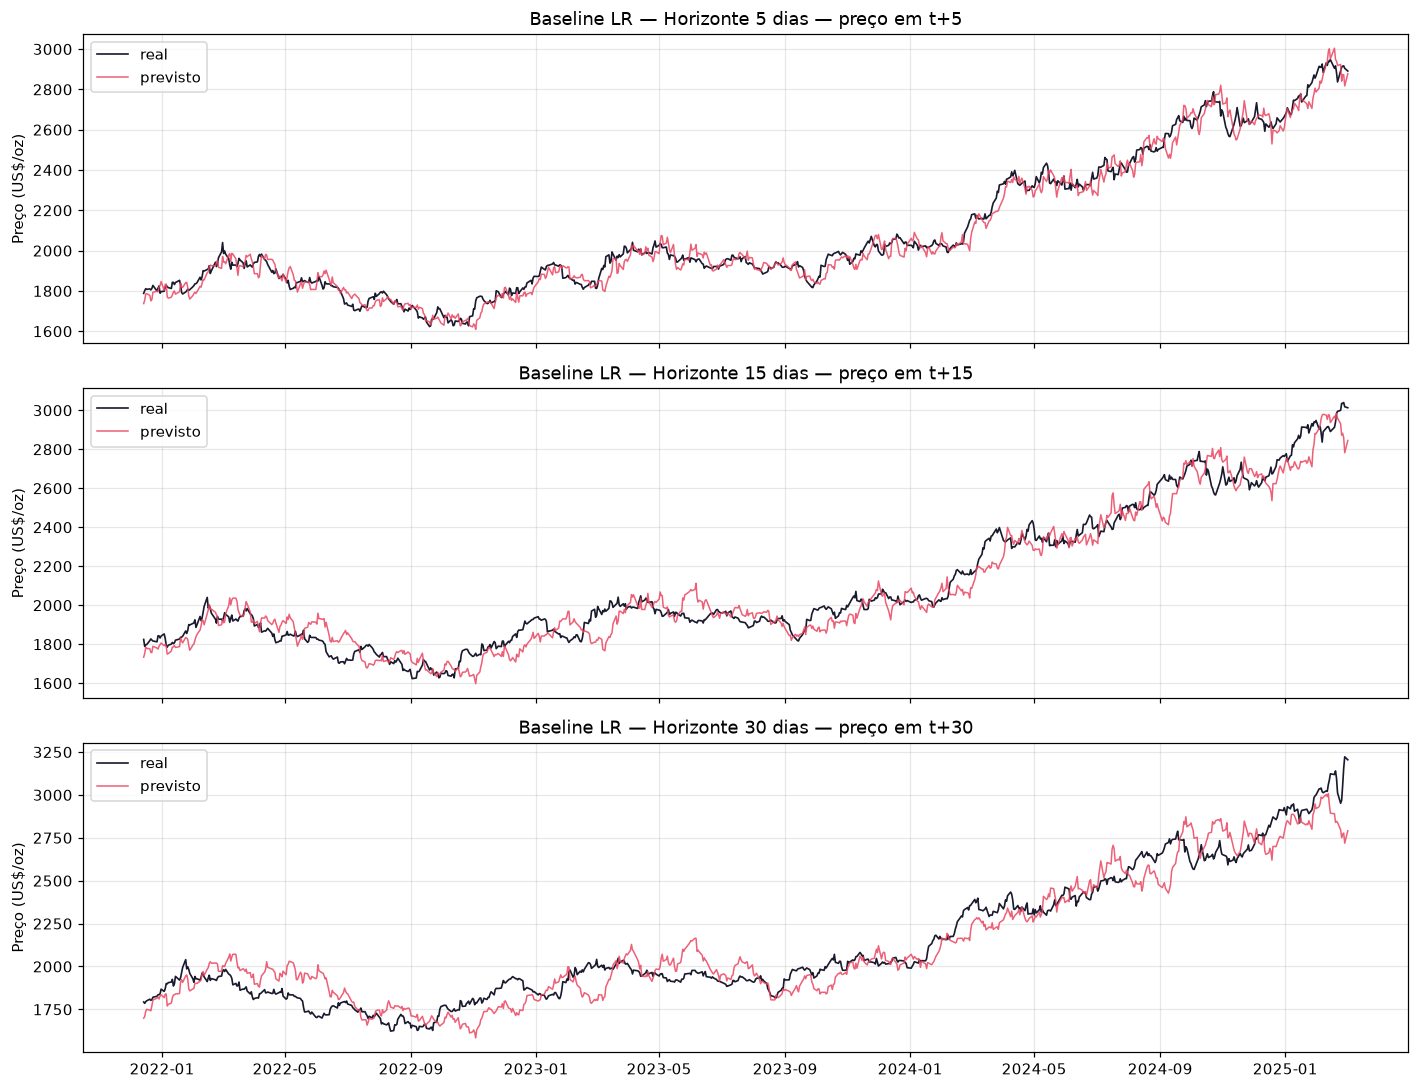

In [12]:
dates_te = df["date"].values[Idx["teste"]]
fig = plot_predicted_vs_actual(
    dates_te,
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    HORIZONS,
    ylabel="Preço (US$/oz)",
    model_name="Baseline LR",
)
plt.show()

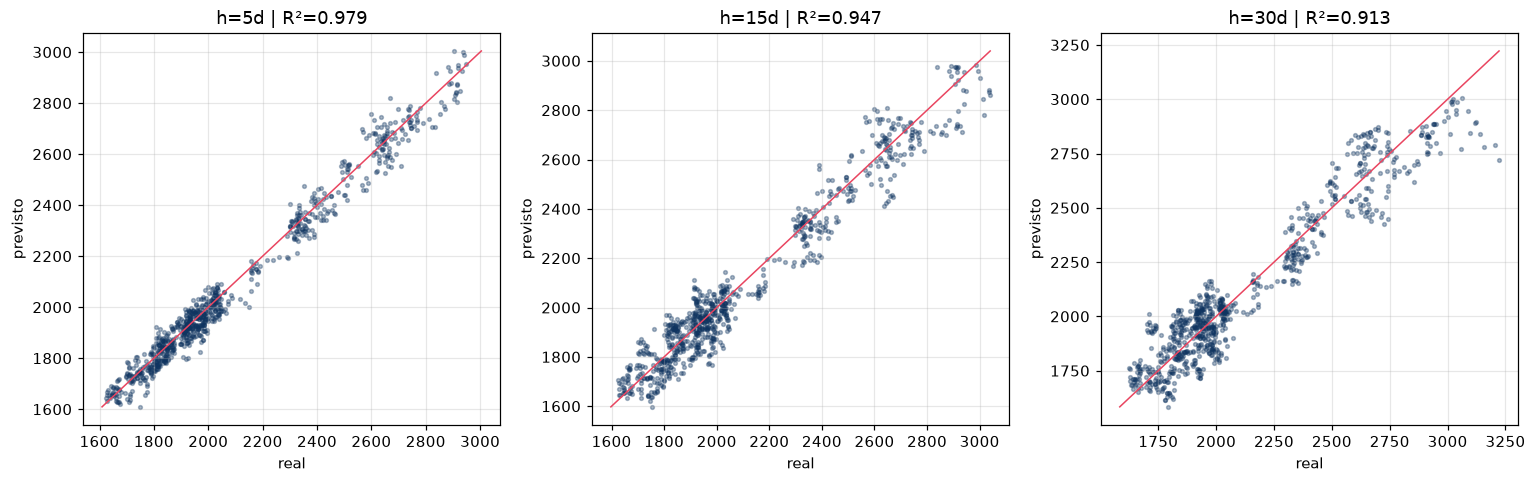

In [13]:
fig = plot_scatter(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    HORIZONS,
)
plt.show()

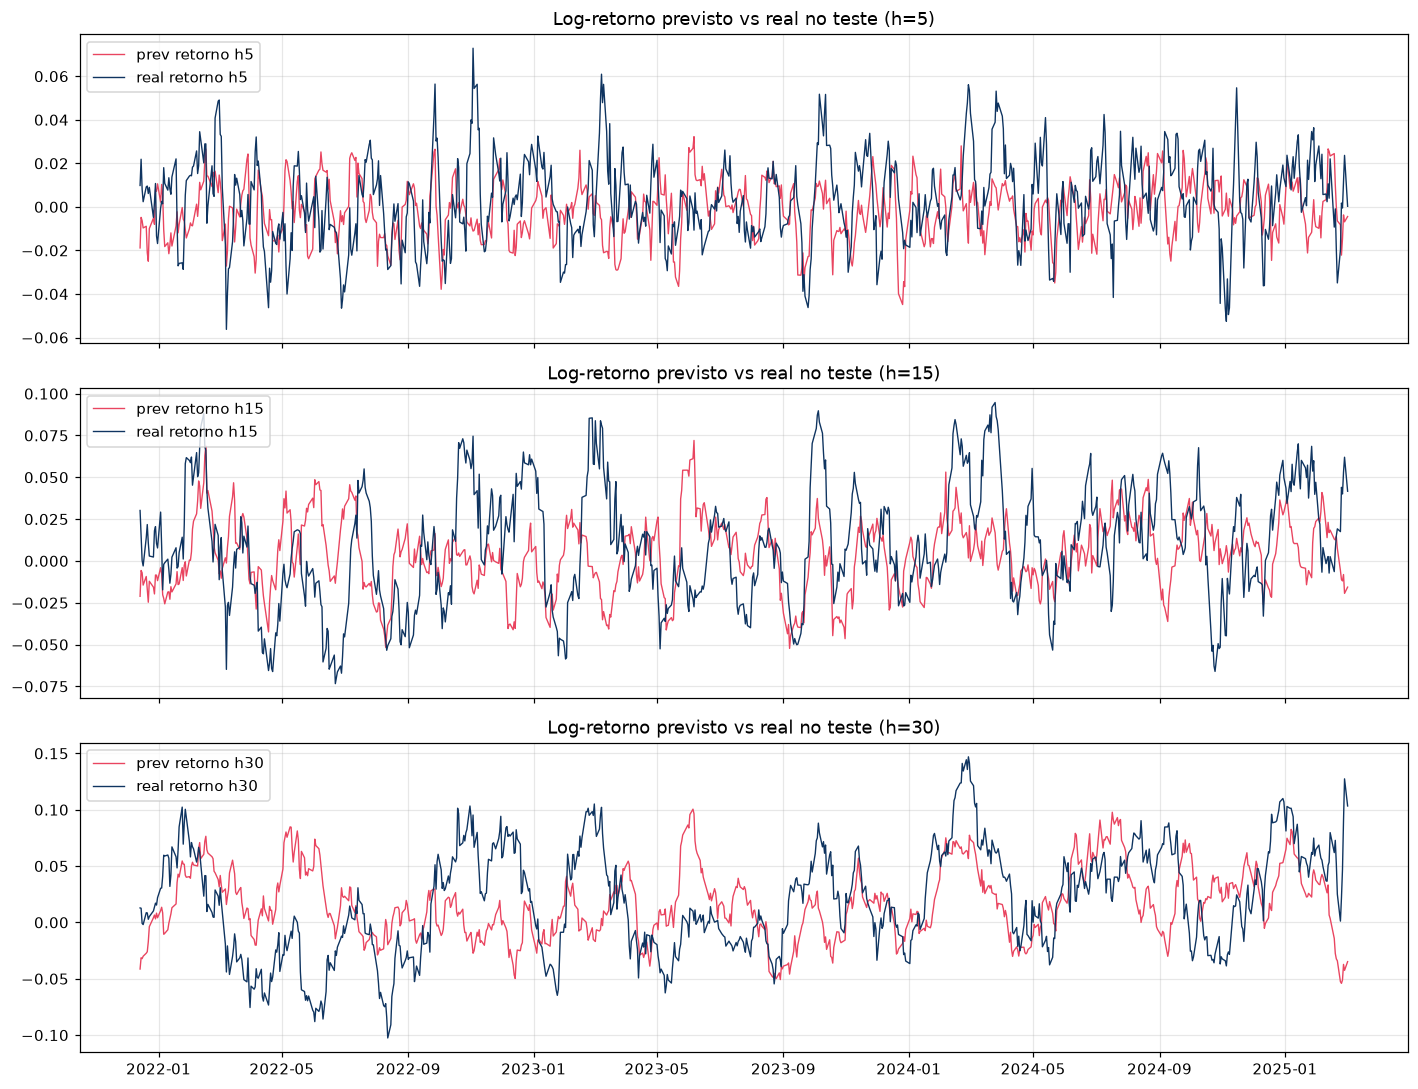

In [14]:
fig = plot_return_predictions(
    dates_te,
    Y["teste"],
    preds["teste"],
    HORIZONS,
)
plt.show()

In [15]:
h30_idx = HORIZONS.index(30)
yearly = per_year_metrics(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    dates_te,
    horizon_idx=h30_idx,
)
yearly

,DirAcc%,MAE/naive
ano,,
2021,53.846154,2.301828
2022,44.621514,1.190505
2023,57.600000,1.208052
2024,70.238095,0.841307
2025,75.609756,0.657090


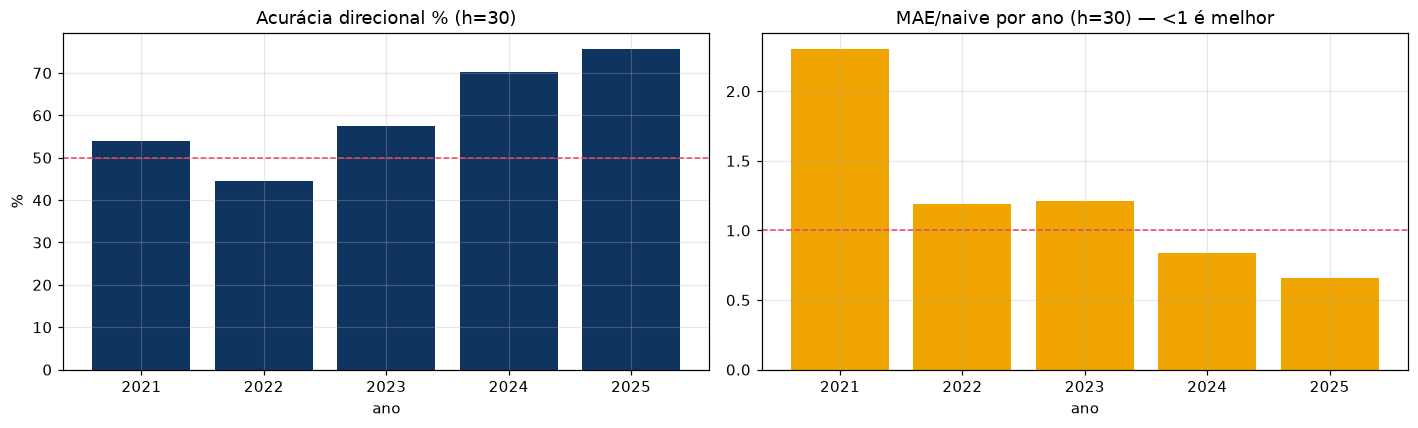

In [16]:
fig = plot_yearly_perf(yearly, horizon=30)
plt.show()

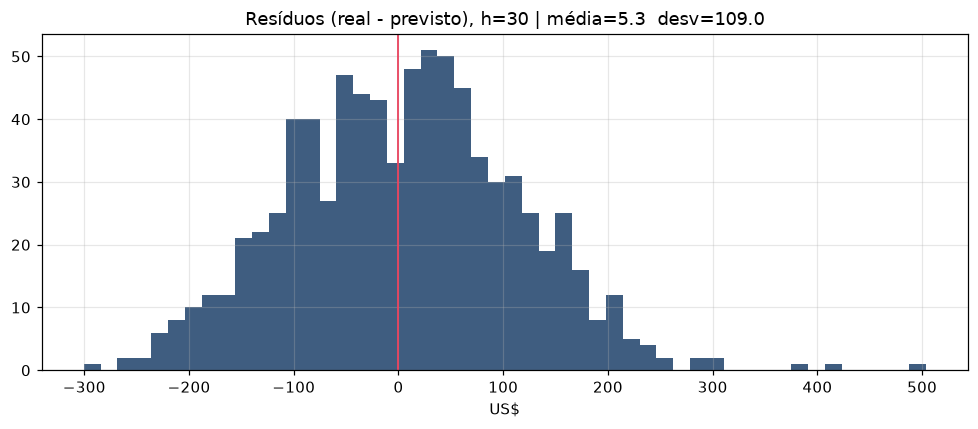

In [17]:
fig = plot_residuals(
    Y["teste"],
    preds["teste"],
    Prices["teste"],
    horizon_idx=h30_idx,
    horizon=30,
)
plt.show()

## Importância dos coeficientes

Top 20 features por magnitude média dos coeficientes nos três horizontes.

In [18]:
coef_df = pd.DataFrame(
    {f"h{h}": np.abs(models[h].coef_) for h in HORIZONS},
    index=window_feature_names,
)
coef_df["mean"] = coef_df.mean(axis=1)
top_coef = coef_df.sort_values("mean", ascending=False).head(20)
top_coef

,h5,h15,h30,mean
ma_cross_t-19,2.022190,3.859990,3.799629,3.227269
ma_cross_t-1,1.857015,2.256850,4.665920,2.926595
ma_cross_t-26,2.696449,0.609077,3.780005,2.361844
ma_cross_t-18,1.529997,2.658739,2.664926,2.284554
ma_cross_t-15,0.495479,2.975448,3.210658,2.227195
ma_cross_t-0,1.572215,0.041743,4.703371,2.105776
ma_cross_t-11,2.153409,1.271532,2.591535,2.005492
ma_cross_t-21,1.788629,2.545145,1.591238,1.975004
ma_cross_t-9,0.881358,1.526963,3.332805,1.913709
ma_cross_t-8,1.472348,1.962874,2.254431,1.896551


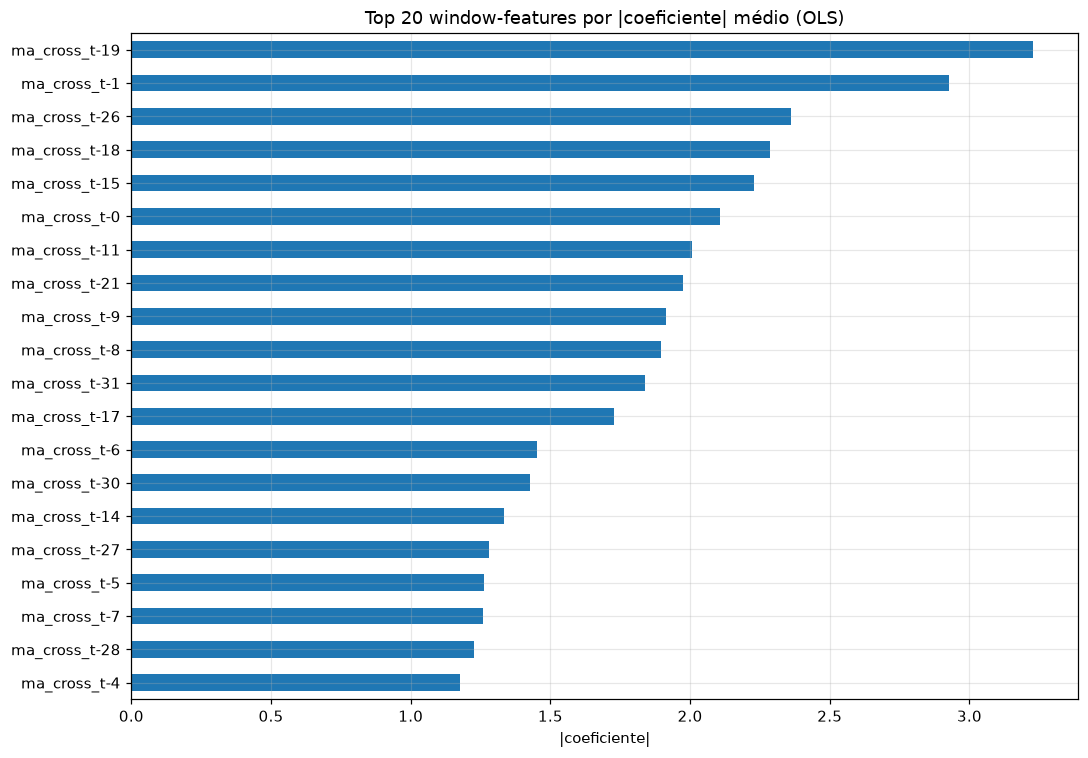

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))
top_coef["mean"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 window-features por |coeficiente| médio (OLS)")
ax.set_xlabel("|coeficiente|")
plt.tight_layout()
plt.show()

## Comparação: Ridge vs OLS

Com 1 140 features, OLS pode ter coeficientes instáveis por multicolinearidade. Ridge adiciona regularização L2 para comparação.

In [20]:
RIDGE_ALPHA = 10.0

models_ridge = {}
preds_ridge = {split: [] for split in ["treino", "val", "teste"]}

for j, h in enumerate(HORIZONS):
    ridge = Ridge(alpha=RIDGE_ALPHA)
    ridge.fit(X["treino"], Y["treino"][:, j])
    models_ridge[h] = ridge

for split in ["treino", "val", "teste"]:
    cols = [models_ridge[h].predict(X[split]) for h in HORIZONS]
    preds_ridge[split] = np.column_stack(cols).astype(np.float32)

tbl_ridge = pd.concat(
    [
        regression_metrics(
            Y[split],
            preds_ridge[split],
            Prices[split],
            HORIZONS,
            split_name=split,
        )
        for split in ["treino", "val", "teste"]
    ],
    ignore_index=True,
)

t_ridge = tbl_ridge[tbl_ridge["split"] == "teste"].set_index("h")[
    ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
]
print(f"Ridge (alpha={RIDGE_ALPHA}) — DESEMPENHO NO TESTE")
print(t_ridge.round(2).to_string())

Ridge (alpha=10.0) — DESEMPENHO NO TESTE
      MAE    RMSE  MAPE%  DirAcc%  MAE/naive
h                                           
5   37.80   47.58   1.80    49.19       1.15
15  64.10   79.96   3.06    58.12       1.07
30  87.07  105.47   4.17    58.61       1.00


## Tabela comparativa final

Baseline OLS e Ridge lado a lado, apenas no conjunto de teste.

In [21]:
cols_show = ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]

t_ols = tbl[tbl["split"] == "teste"].set_index("h")[cols_show].add_suffix("_OLS")
t_rdg = (
    tbl_ridge[tbl_ridge["split"] == "teste"]
    .set_index("h")[cols_show]
    .add_suffix("_Ridge")
)

comparativo = pd.concat([t_ols, t_rdg], axis=1).round(2)
print("Comparativo OLS vs Ridge (teste)")
comparativo

Comparativo OLS vs Ridge (teste)


,MAE_OLS,RMSE_OLS,MAPE%_OLS,DirAcc%_OLS,MAE/naive_OLS,MAE_Ridge,RMSE_Ridge,MAPE%_Ridge,DirAcc%_Ridge,MAE/naive_Ridge
h,,,,,,,,,,
5,38.23,48.20,1.82,52.54,1.16,37.80,47.58,1.80,49.19,1.15
15,63.87,80.22,3.05,55.02,1.07,64.10,79.96,3.06,58.12,1.07
30,87.66,109.09,4.16,58.36,1.00,87.07,105.47,4.17,58.61,1.00
